In [ ]:
import numpy as np
from time import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import BoundaryNorm

Для начала сгенерируем бинарные нелинейно разделимые данные

In [40]:
def balanced_kmeans(points, k, target_size, seed=42):
    n_points = len(points)
    assert n_points == k * target_size, "Total points must be k * target_size"

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = kmeans.fit_predict(points)
    centroids = kmeans.cluster_centers_

    sizes = np.bincount(labels, minlength=k)
    while np.any(sizes != target_size):
        donor = np.where(sizes > target_size)[0][0]
        receiver = np.where(sizes < target_size)[0][0]

        donor_points = points[labels == donor]
        donor_indices = np.where(labels == donor)[0]
        dist_to_receiver = cdist(donor_points, centroids[receiver:receiver+1]).flatten()
        best_idx = np.argmin(dist_to_receiver)
        point_to_move = donor_indices[best_idx]

        labels[point_to_move] = receiver
        sizes[donor] -= 1
        sizes[receiver] += 1

        for i in range(k):
            if sizes[i] > 0:
                centroids[i] = np.mean(points[labels == i], axis=0)

    return labels, centroids

def adjust_class_distances(points, labels, classes, threshold):
    # Work on float copy to avoid integer/float conflict
    points_adj = points.astype(np.float64)
    centroids = np.array([np.mean(points_adj[labels == i], axis=0) for i in range(classes)])

    while True:
        dist_matrix = cdist(centroids, centroids)
        violations = np.where(dist_matrix > threshold)
        if len(violations[0]) == 0:
            break

        i, j = violations[0][0], violations[1][0]
        if i >= j:
            continue

        dist = dist_matrix[i, j]
        norm_i = np.linalg.norm(centroids[i])
        norm_j = np.linalg.norm(centroids[j])

        if norm_i >= norm_j:
            fixed = centroids[j]
            moving = centroids[i]
            move_class = i
        else:
            fixed = centroids[i]
            moving = centroids[j]
            move_class = j

        direction = moving - fixed
        new_moving = fixed + direction * (threshold / dist)
        translation = new_moving - moving

        points_adj[labels == move_class] += translation
        centroids[move_class] = new_moving

    return points_adj, labels

def generate_class_clouds(classes, clusters, dims, scale_val, alpha,
                          points_per_center, cloud_sigma, seed=None):
    """
    Generate points grouped into classes:
    1. Create `classes * clusters` initial integer points.
    2. Partition them into `classes` equal‑sized groups using balanced k‑means.
    3. Adjust the positions of entire groups so that all group centroids are
       within `scale_val * alpha` of each other.
    4. For each point, generate a Gaussian cloud of `points_per_center` points.
    """
    if seed is not None:
        np.random.seed(seed)

    total_centers = classes * clusters
    centers = np.random.randint(-scale_val, scale_val, size=(total_centers, dims))

    # Balanced partitioning
    center_labels, _ = balanced_kmeans(centers, classes, clusters, seed=seed)

    # Adjust class centroids to enforce distance constraint
    threshold = scale_val * alpha
    centers_adj, _ = adjust_class_distances(centers, center_labels, classes, threshold)

    # Generate clouds around each adjusted center
    all_points = []
    all_labels = []
    for center, cls in zip(centers_adj, center_labels):
        noise = np.random.randn(points_per_center, dims) * cloud_sigma
        cloud = center + noise
        all_points.append(cloud)
        all_labels.append(np.full(points_per_center, cls, dtype=int))

    points = np.vstack(all_points)
    labels = np.concatenate(all_labels)
    return points, labels


In [41]:
class DenseLayer:
    def __init__(self, input_size, output_size, activation='relu'):
        # Инициализация весов (He для ReLU, Xavier для сигмоиды)
        if activation == 'relu':
            self.W = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
        else:
            self.W = np.random.randn(input_size, output_size) * np.sqrt(1.0 / input_size)
        self.b = np.zeros((1, output_size))
        self.activation = activation
        self.input = None
        self.z = None
        self.output = None

    def forward(self, X):
        self.input = X
        self.z = np.dot(X, self.W) + self.b
        if self.activation == 'relu':
            self.output = np.maximum(0, self.z)
        elif self.activation == 'sigmoid':
            self.output = 1 / (1 + np.exp(-self.z))
        else:  # linear
            self.output = self.z
        return self.output

    def backward(self, dout):
        # dout - градиент потерь по выходу слоя
        if self.activation == 'relu':
            dact = (self.z > 0).astype(float)
            dout = dout * dact
        elif self.activation == 'sigmoid':
            sig = self.output
            dout = dout * sig * (1 - sig)

        self.dW = np.dot(self.input.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)
        self.dX = np.dot(dout, self.W.T)
        return self.dX

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [42]:
class Conv2DLayer:
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, activation='relu'):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)
        self.activation = activation

        # Инициализация весов (He для ReLU, Xavier для остальных)
        fan_in = in_channels * self.kernel_size[0] * self.kernel_size[1]
        if activation == 'relu':
            scale = np.sqrt(2.0 / fan_in)
        else:
            scale = np.sqrt(1.0 / fan_in)
        self.W = np.random.randn(out_channels, in_channels, self.kernel_size[0], self.kernel_size[1]) * scale
        self.b = np.zeros((1, out_channels, 1, 1))

        # Буферы
        self.X = None
        self.X_col = None
        self.W_col = None
        self.z = None
        self.output = None

    def _im2col(self, X):
        """Преобразует входной тензор в матрицу столбцов (каждый столбец – свёрточное окно)."""
        batch, in_c, h, w = X.shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        h_out = (h + 2*ph - kh) // sh + 1
        w_out = (w + 2*pw - kw) // sw + 1

        # Дополняем нулями
        X_pad = np.pad(X, ((0,0), (0,0), (ph,ph), (pw,pw)), mode='constant')

        # Индексы для окон по высоте и ширине
        i0 = np.repeat(np.arange(kh), kw)               # (kh*kw,)
        i0 = np.tile(i0, in_c)                         # (in_c*kh*kw,)
        j0 = np.tile(np.arange(kw), kh * in_c)         # (in_c*kh*kw,)

        i1 = sh * np.repeat(np.arange(h_out), w_out)   # (h_out*w_out,)
        j1 = sw * np.tile(np.arange(w_out), h_out)     # (h_out*w_out,)

        # Формируем матрицу столбцов
        # X_pad[:, :, i0[:, None] + i1[None, :], j0[:, None] + j1[None, :]] -> shape (batch, in_c, in_c*kh*kw, h_out*w_out) ? Неправильно.
        # Правильный способ: для каждого канала и каждого окна собираем вектор.
        # Создаём пустую матрицу (in_c*kh*kw, batch*h_out*w_out)
        X_col = np.zeros((in_c * kh * kw, batch * h_out * w_out), dtype=X.dtype)

        for b in range(batch):
            for i in range(h_out):
                for j in range(w_out):
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    # Окно: (in_c, kh, kw) -> вытягиваем в вектор
                    patch = X_pad[b, :, h_start:h_end, w_start:w_end].reshape(-1)
                    col_idx = b * (h_out * w_out) + i * w_out + j
                    X_col[:, col_idx] = patch
        return X_col, (h_out, w_out)

    def _col2im(self, dX_col, X_shape):
        """Обратное преобразование: из градиента по столбцам в градиент по входу."""
        batch, in_c, h, w = X_shape
        kh, kw = self.kernel_size
        sh, sw = self.stride
        ph, pw = self.padding

        h_out = (h + 2*ph - kh) // sh + 1
        w_out = (w + 2*pw - kw) // sw + 1

        dX_pad = np.zeros((batch, in_c, h + 2*ph, w + 2*pw), dtype=dX_col.dtype)
        dX_col = dX_col.reshape(in_c * kh * kw, batch, h_out * w_out)

        for b in range(batch):
            for i in range(h_out):
                for j in range(w_out):
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    # Восстанавливаем градиент окна
                    patch_grad = dX_col[:, b, i * w_out + j].reshape(in_c, kh, kw)
                    dX_pad[b, :, h_start:h_end, w_start:w_end] += patch_grad

        # Обрезаем padding
        if ph > 0 or pw > 0:
            return dX_pad[:, :, ph:-ph, pw:-pw]
        else:
            return dX_pad

    def forward(self, X):
        self.X = X
        batch, in_c, h, w = X.shape

        # im2col
        self.X_col, (h_out, w_out) = self._im2col(X)

        # Веса в матрицу (out_channels, in_c*kh*kw)
        self.W_col = self.W.reshape(self.out_channels, -1)

        # Линейная часть
        z = np.dot(self.W_col, self.X_col) + self.b.reshape(-1, 1)  # (out_channels, batch*h_out*w_out)
        self.z = z.T.reshape(batch, self.out_channels, h_out, w_out)

        # Активация
        if self.activation == 'relu':
            self.output = np.maximum(0, self.z)
        elif self.activation == 'sigmoid':
            self.output = 1 / (1 + np.exp(-self.z))
        else:
            self.output = self.z
        return self.output

    def backward(self, dout):
        batch, out_c, h_out, w_out = dout.shape
        kh, kw = self.kernel_size
        in_c = self.in_channels

        # Производная активации
        if self.activation == 'relu':
            dout = dout * (self.z > 0).astype(float)
        elif self.activation == 'sigmoid':
            dout = dout * self.output * (1 - self.output)

        # dout -> (out_channels, batch*h_out*w_out)
        dout_flat = dout.transpose(1, 0, 2, 3).reshape(out_c, -1)

        # Градиент по весам
        self.dW = np.dot(dout_flat, self.X_col.T).reshape(self.W.shape)
        # Градиент по смещению
        self.db = np.sum(dout_flat, axis=1, keepdims=True).reshape(1, out_c, 1, 1)

        # Градиент по входу
        dX_col = np.dot(self.W_col.T, dout_flat)
        self.dX = self._col2im(dX_col, self.X.shape)

        return self.dX

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [43]:
class MaxPool2D:
    """Слой максимального пулинга (без весов)."""
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size if isinstance(pool_size, tuple) else (pool_size, pool_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.X = None
        self.mask = None   # для запоминания позиций максимумов

    def forward(self, X):
        self.X = X
        batch, ch, h, w = X.shape
        ph, pw = self.pool_size
        sh, sw = self.stride

        h_out = (h - ph) // sh + 1
        w_out = (w - pw) // sw + 1

        output = np.zeros((batch, ch, h_out, w_out))
        self.mask = np.zeros_like(X, dtype=bool)

        for i in range(h_out):
            for j in range(w_out):
                h_start = i * sh
                h_end = h_start + ph
                w_start = j * sw
                w_end = w_start + pw

                patch = X[:, :, h_start:h_end, w_start:w_end]
                # Находим максимум по пространственным осям (kh, kw)
                max_val = np.max(patch, axis=(2, 3), keepdims=True)
                output[:, :, i, j] = max_val.squeeze()

                # Маска: где максимум (сравнение patch с max_val)
                mask_patch = (patch == max_val)
                self.mask[:, :, h_start:h_end, w_start:w_end] |= mask_patch

        return output

    def backward(self, dout):
        # dout shape: (batch, ch, h_out, w_out)
        dX = np.zeros_like(self.X)
        batch, ch, h_out, w_out = dout.shape
        ph, pw = self.pool_size
        sh, sw = self.stride

        for i in range(h_out):
            for j in range(w_out):
                h_start = i * sh
                h_end = h_start + ph
                w_start = j * sw
                w_end = w_start + pw
                # Копируем градиент только в позиции максимумов
                dX[:, :, h_start:h_end, w_start:w_end] += \
                    dout[:, :, i:i+1, j:j+1] * self.mask[:, :, h_start:h_end, w_start:w_end]
        return dX

    def update(self, lr):
        pass   # нет обучаемых параметров


class Flatten:
    """Преобразует (batch, C, H, W) → (batch, C*H*W)"""
    def __init__(self):
        self.input_shape = None

    def forward(self, X):
        self.input_shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.input_shape)

    def update(self, lr):
        pass

In [44]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activations):
        self.layers = []
        for i in range(len(layer_sizes)-1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], activations[i]))

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, loss_grad):
        grad = loss_grad
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def train_step(self, X, y, loss_fn, lr):
        # Прямой проход
        y_pred = self.forward(X)
        # Вычисление потерь и градиента по выходу
        loss, dout = loss_fn(y_pred, y)
        # Обратный проход
        self.backward(dout)
        # Обновление весов
        self.update(lr)
        return loss
    
    def predict(self, X):
        """Предсказание для входных данных X."""
        return self.forward(X)

In [45]:
class CNN:
    def __init__(self, layers):
        self.layers = layers   # список объектов слоёв

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, loss_grad):
        grad = loss_grad
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def train_step(self, X, y, loss_fn, lr):
        y_pred = self.forward(X)
        loss, dout = loss_fn(y_pred, y)
        self.backward(dout)
        self.update(lr)
        return loss

    def predict(self, X):
        return self.forward(X)

In [46]:
# Функции потерь с защитой от неверной размерности
def mse(pred, true):
    # Приводим true к той же размерности, что и pred
    if true.ndim == 1:
        true = true.reshape(-1, 1)
    return np.mean((pred - true) ** 2), 2 * (pred - true) / len(pred)

def softmax_cross_entropy(y_pred, y_onehot):
    # y_pred — логиты (batch, classes)
    shifted = y_pred - np.max(y_pred, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-15), axis=1))
    dlogits = (probs - y_onehot) / y_pred.shape[0]
    return loss, dlogits

In [47]:
def predict_classification(model, X, task='multiclass', threshold=0.5, return_probs=False):
    """
    Выполняет предсказание классов (и вероятностей) для входных данных.
    
    Параметры:
    ----------
    model : NeuralNetwork
        Обученная модель нейронной сети.
    X : np.ndarray
        Входные данные формы (n_samples, n_features).
    task : str
        Тип задачи: 'binary' (бинарная классификация) или 'multiclass' (многоклассовая).
        Для 'binary' применяется sigmoid и порог; для 'multiclass' - softmax и argmax.
    threshold : float
        Порог для бинарной классификации (по умолчанию 0.5).
    return_probs : bool
        Если True, возвращает также вероятности классов.
    
    Возвращает:
    -----------
    Если return_probs=False:
        pred_classes : np.ndarray
            Предсказанные классы.
    Если return_probs=True:
        (pred_classes, probs) : tuple
            pred_classes - предсказанные классы,
            probs - вероятности классов (для бинарной - (n_samples, 1), для multiclass - (n_samples, n_classes)).
    """
    # Прямой проход через сеть
    logits = model.predict(X)  # форма (n_samples, n_classes)
    
    # Преобразование в вероятности и классы
    if task == 'binary':
        # Для бинарной классификации предполагаем, что выход имеет 1 нейрон
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
        pred_classes = (probs >= threshold).astype(int).flatten()
        if return_probs:
            return pred_classes, probs.flatten()
        return pred_classes
    elif task == 'multiclass':
        # Стабильный softmax
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        pred_classes = np.argmax(probs, axis=1)
        if return_probs:
            return pred_classes, probs
        return pred_classes
    else:
        raise ValueError("task должен быть 'binary' или 'multiclass'")

def classification_metrics(y_true, y_pred, task='multiclass', average='macro'):
    """
    Вычисляет метрики классификации по истинным и предсказанным меткам.
    
    Параметры:
    ----------
    y_true : np.ndarray
        Истинные метки классов (n_samples,).
    y_pred : np.ndarray
        Предсказанные метки классов (n_samples,).
    task : str
        Тип задачи: 'binary' или 'multiclass'. Влияет на способ вычисления метрик.
    average : str
        Для многоклассовой классификации: 'macro', 'micro', 'weighted' или None.
        По умолчанию 'macro'. Используется только если доступен scikit-learn.
    
    Возвращает:
    -----------
    dict : словарь с ключами:
        - 'accuracy': accuracy
        - 'precision': precision
        - 'recall': recall
        - 'f1': f1-score
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.ndim > 1:
        y_true = y_true.flatten()
    if y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    
    # Accuracy
    accuracy = np.mean(y_true == y_pred)
    
    # Если есть sklearn, используем его для precision/recall/f1
    try:
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(y_true, y_pred, average=average, zero_division=0)
        recall = recall_score(y_true, y_pred, average=average, zero_division=0)
        f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    except ImportError:
        # Ручной расчёт для бинарной классификации
        if task == 'binary':
            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        else:
            # Для многоклассовой без sklearn возвращаем None, но предупреждаем
            print("Для многоклассовой классификации установите библиотеку scikit-learn")
            precision = recall = f1 = None
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [48]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        """Вычисляет параметры по обучающим данным."""
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        # Защита от деления на ноль
        self.std[self.std == 0] = 1.0
        return self

    def transform(self, X):
        """Применяет нормализацию."""
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_norm):
        """Возвращает исходный масштаб."""
        return X_norm * self.std + self.mean

In [49]:
def plot_classification_results(X_train, X_test, y_train, y_test, y_pred,
                                dim_reducer='pca',
                                title='Classification Results', figsize=(10, 8)):
    """
    Визуализирует обучающую и тестовую выборки с результатами классификации.
    При необходимости уменьшает размерность до 2D с помощью PCA или другого reducer.

    Параметры:
    ----------
    X_train : np.ndarray, shape (n_train, n_features)
        Признаки обучающей выборки.
    X_test : np.ndarray, shape (n_test, n_features)
        Признаки тестовой выборки.
    y_train : np.ndarray, shape (n_train,)
        Истинные метки классов для обучающей выборки.
    y_test : np.ndarray, shape (n_test,)
        Истинные метки классов для тестовой выборки.
    y_pred : np.ndarray, shape (n_test,)
        Предсказанные метки для тестовой выборки.
    dim_reducer : str or object or None
        Способ уменьшения размерности. Возможные значения:
        - None : данные уже 2D (X.shape[1] == 2).
        - 'pca' : использовать PCA (по умолчанию).
        - объект с методами fit_transform и transform (например, обученный PCA).
    title : str
        Заголовок графика.
    figsize : tuple
        Размер фигуры.
    """
    # Приводим метки к плоскому виду
    y_train = np.asarray(y_train).flatten()
    y_test = np.asarray(y_test).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # --- Уменьшение размерности до 2D ---
    if dim_reducer is None:
        # Данные должны быть 2D
        if X_train.shape[1] != 2 or X_test.shape[1] != 2:
            raise ValueError("dim_reducer=None, но входные данные не 2D. Используйте 'pca' или другой редуктор.")
        X_train_2d = X_train
        X_test_2d = X_test
    elif dim_reducer == 'pca':
        # Обучаем PCA только на обучающих данных
        pca = PCA(n_components=2)
        X_train_2d = pca.fit_transform(X_train)
        X_test_2d = pca.transform(X_test)
        print(f"PCA объясняет {pca.explained_variance_ratio_.sum():.2%} дисперсии.")
    elif dim_reducer == 'tsne':
        tsne = TSNE(n_components=2, random_state=seed)
        X_combined = np.vstack([X_train, X_test])
        X_combined_2d = tsne.fit_transform(X_combined)
        X_train_2d = X_combined_2d[:len(X_train)]
        X_test_2d = X_combined_2d[len(X_train):]
        print("t-SNE выполнен.")
    else:
        # Пользовательский reducer (должен иметь методы fit_transform и transform)
        try:
            X_train_2d = dim_reducer.fit_transform(X_train)
            X_test_2d = dim_reducer.transform(X_test)
        except AttributeError:
            raise ValueError("dim_reducer должен быть объектом с методами fit_transform и transform, или 'pca', или None.")

    # --- Далее код как раньше, но с X_train_2d, X_test_2d ---
    unique_classes = np.unique(np.concatenate([y_train, y_test]))
    n_classes = len(unique_classes)
    colormap = plt.get_cmap('tab10', n_classes)
    colors = {cls: colormap(i) for i, cls in enumerate(unique_classes)}

    plt.figure(figsize=figsize)

    # Обучающие точки
    for cls in unique_classes:
        mask = (y_train == cls)
        if np.any(mask):
            plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                        color=colors[cls], marker='o', s=30, alpha=0.7, edgecolors='none',
                        label=f'Train class {cls}')

    correct_mask = (y_pred == y_test)
    incorrect_mask = ~correct_mask

    # Правильно предсказанные
    for cls in unique_classes:
        mask = correct_mask & (y_test == cls)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=colors[cls], marker='o', s=60, alpha=0.8,
                        edgecolors='green', linewidths=1.5,
                        label=f'Correct: class {cls}')

    # Неправильно предсказанные
    for cls in unique_classes:
        mask = incorrect_mask & (y_test == cls)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=colors[cls], marker='x', s=70, alpha=0.9,
                         linewidths=1.5, # edgecolors='red',
                        label=f'Incorrect: class {cls}')

    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.title(title)
    plt.xlabel('Component 1' if dim_reducer else 'Feature 1')
    plt.ylabel('Component 2' if dim_reducer else 'Feature 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [50]:
def plot_classification_regions(model, X_train, X_test, y_train, y_test, y_pred,
                                task='multiclass', threshold=0.5,
                                resolution=100, padding=0.5,
                                title='Classification Results with Decision Regions',
                                figsize=(10, 8), dim_reducer=None):
    """
    Визуализирует обучающую и тестовую выборки с результатами классификации,
    а также отображает решающие области модели с помощью contourf.
    При необходимости уменьшает размерность до 2D с помощью PCA или другого reducer
    (должен поддерживать inverse_transform для построения сетки).

    Параметры:
    ----------
    model : обученная модель с методом predict (или forward)
    X_train, X_test : массивы признаков (может быть >2)
    y_train, y_test, y_pred : метки классов
    task, threshold : параметры predict_classification
    resolution : разрешение сетки
    padding : отступ вокруг данных
    title, figsize : параметры графика
    dim_reducer : str or object or None
        - None : данные считаются уже 2D
        - 'pca' : использовать PCA (обученный на X_train)
        - объект с методами fit_transform, transform и inverse_transform
    """
    # Приводим метки к плоскому виду
    y_train = np.asarray(y_train).flatten()
    y_test = np.asarray(y_test).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # --- Уменьшение размерности и подготовка 2D данных ---
    if dim_reducer is None:
        if X_train.shape[1] != 2 or X_test.shape[1] != 2:
            raise ValueError("dim_reducer=None, но входные данные не 2D. Используйте 'pca' или другой редуктор.")
        X_train_2d = X_train
        X_test_2d = X_test
        use_inverse = False   # для единообразия, но контуры строим отдельно
    elif dim_reducer == 'pca':
        pca = PCA(n_components=2)
        X_train_2d = pca.fit_transform(X_train)
        X_test_2d = pca.transform(X_test)
        print(f"PCA объясняет {pca.explained_variance_ratio_.sum():.2%} дисперсии.")
        reducer = pca
        use_inverse = True
    elif dim_reducer == 'tsne':
        tsne = TSNE(n_components=2, random_state=42)
        X_combined = np.vstack([X_train, X_test])
        X_combined_2d = tsne.fit_transform(X_combined)
        X_train_2d = X_combined_2d[:len(X_train)]
        X_test_2d = X_combined_2d[len(X_train):]
        print("t-SNE выполнен.")
        reducer = tsne
        use_inverse = False  # t-SNE не поддерживает обратное преобразование
    else:
        # Пользовательский reducer
        try:
            X_train_2d = dim_reducer.fit_transform(X_train)
            X_test_2d = dim_reducer.transform(X_test)
            reducer = dim_reducer
            use_inverse = hasattr(reducer, 'inverse_transform')
            if not use_inverse:
                print("Внимание: переданный reducer не поддерживает inverse_transform. Контурные области построены не будут.")
        except AttributeError:
            raise ValueError("dim_reducer должен быть объектом с методами fit_transform и transform, или 'pca', или None.")

    # --- Подготовка данных для контурных областей ---
    # Определяем, можем ли мы построить сетку:
    # 1) если данные уже 2D (dim_reducer is None) -> строим сетку в исходном пространстве
    # 2) если есть inverse_transform -> строим сетку в 2D и преобразуем обратно
    if dim_reducer is None:
        # Данные уже двумерные, строим сетку в этом же пространстве
        x_min = X_train_2d[:, 0].min() - padding
        x_max = X_train_2d[:, 0].max() + padding
        y_min = X_train_2d[:, 1].min() - padding
        y_max = X_train_2d[:, 1].max() + padding
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                             np.linspace(y_min, y_max, resolution))
        grid_2d = np.c_[xx.ravel(), yy.ravel()]
        # Предсказываем классы для точек сетки напрямую
        grid_pred = predict_classification(model, grid_2d, task=task, threshold=threshold)
        use_contour = True
    elif use_inverse:
        x_min = X_train_2d[:, 0].min() - padding
        x_max = X_train_2d[:, 0].max() + padding
        y_min = X_train_2d[:, 1].min() - padding
        y_max = X_train_2d[:, 1].max() + padding
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                             np.linspace(y_min, y_max, resolution))
        grid_2d = np.c_[xx.ravel(), yy.ravel()]
        grid_original = reducer.inverse_transform(grid_2d)
        grid_pred = predict_classification(model, grid_original, task=task, threshold=threshold)
        use_contour = True
    else:
        use_contour = False
        print("Контурные области не построены: нет обратного преобразования или данные не 2D.")

    # --- Построение графика ---
    # Единое отображение классов в индексы
    unique_classes = np.unique(np.concatenate([y_train, y_test]))
    n_classes = len(unique_classes)
    class_to_index = {cls: i for i, cls in enumerate(unique_classes)}
    y_train_idx = np.array([class_to_index[c] for c in y_train])
    y_test_idx = np.array([class_to_index[c] for c in y_test])
    y_pred_idx = np.array([class_to_index[c] for c in y_pred])

    # Цветовая карта (исправлено устаревшее get_cmap)
    cmap = plt.get_cmap('tab10', n_classes)
    norm = BoundaryNorm(np.arange(n_classes + 1) - 0.5, n_classes)

    plt.figure(figsize=figsize)

    # Контурные области
    if use_contour:
        grid_pred_idx = np.array([class_to_index[c] for c in grid_pred])
        Z = grid_pred_idx.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=cmap, norm=norm, alpha=0.3)

    # Обучающие точки
    # for idx, cls in enumerate(unique_classes):
    #     mask = (y_train_idx == idx)
    #     if np.any(mask):
    #         plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
    #                     color=cmap(idx), marker='o', s=30, alpha=0.7, edgecolors='none',
    #                     label=f'Train class {cls}')

    # Тестовые точки: правильно и неправильно предсказанные
    correct = (y_pred_idx == y_test_idx)
    incorrect = ~correct

    for idx, cls in enumerate(unique_classes):
        # Правильно предсказанные
        mask = correct & (y_test_idx == idx)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=cmap(idx), marker='o', s=60, alpha=0.8,
                        edgecolors='green', linewidths=1.5,
                        label=f'Correct: class {cls}')
        # Неправильно предсказанные (исправлено: убран edgecolors для маркера 'x')
        mask = incorrect & (y_test_idx == idx)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=cmap(idx), marker='x', s=70, alpha=0.9,
                        label=f'Incorrect: class {cls}')

    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.title(title)
    if dim_reducer is None:
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
    else:
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [51]:
def generate_class_images(classes=10, pictures_per_class=200, length=256,
                          similarity=0.1, func_type='trigonometric',
                          amplitude=1.0, exponent=1.0, noise_level=0.0,
                          seed=None, func_kwargs=None):
    """
    Генерирует синтетические изображения на основе параметрической функции.
    func_type: 'polynomial', 'trigonometric', 'radial', 'spiral'
    """
    if seed is not None:
        np.random.seed(seed)

    n_samples = classes * pictures_per_class
    H = W = length

    # Количество параметров для каждого типа
    if func_type == 'polynomial':
        n_params = 6
    elif func_type == 'trigonometric':
        n_params = 8
    elif func_type == 'radial':
        n_params = 5
    elif func_type == 'spiral':
        n_params = 6
    else:
        raise ValueError("Unknown func_type")

    # Генерация центров классов
    centers = np.random.randn(classes, n_params)
    centroid = centers.mean(axis=0, keepdims=True)
    centers_centered = centers - centroid
    mean_dist = np.mean(np.linalg.norm(centers_centered, axis=1))
    if mean_dist > 0:
        scale = similarity / mean_dist
        centers_scaled = centroid + centers_centered * scale
    else:
        centers_scaled = centers.copy()

    x = np.arange(H)
    y = np.arange(W)
    xx, yy = np.meshgrid(x, y, indexing='ij')

    X_list, y_list = [], []
    intra_class_noise = similarity * 0.2

    for cls in range(classes):
        center = centers_scaled[cls]
        for _ in range(pictures_per_class):
            params = center + np.random.randn(n_params) * intra_class_noise

            if func_type == 'polynomial':
                a, b, c, d, e, f = params
                Z = (a * xx**2 + b * yy**2 + c * xx*yy +
                     d * xx + e * yy + f)
            elif func_type == 'trigonometric':
                A1, A2, B1, B2, C1, C2, D, E = params
                Z = (A1 * np.sin(2*np.pi*xx/length * B1) +
                     A2 * np.cos(2*np.pi*yy/length * B2) +
                     C1 * np.sin(2*np.pi*(xx+yy)/length * C2) +
                     D * xx/length + E * yy/length)
            elif func_type == 'radial':
                cx, cy, sigma, amp, offset = params
                r2 = (xx - cx)**2 + (yy - cy)**2
                Z = amp * np.exp(-r2 / (2*sigma**2)) + offset
            elif func_type == 'spiral':
                a, b, omega, phi, amp, offset = params
                r = np.sqrt(xx**2 + yy**2)
                theta = np.arctan2(yy, xx)
                spiral = a + b * theta
                Z = amp * np.sin(omega * (r - spiral) + phi) + offset
            else:
                raise ValueError

            Z = Z * amplitude
            if exponent != 1.0:
                Z = np.sign(Z) * (np.abs(Z) ** exponent)

            Z_min, Z_max = Z.min(), Z.max()
            if Z_max > Z_min:
                Z_norm = (Z - Z_min) / (Z_max - Z_min) * 255
            else:
                Z_norm = np.zeros_like(Z)

            if noise_level > 0:
                noise = np.random.randn(H, W) * (noise_level * 255)
                Z_norm = np.clip(Z_norm + noise, 0, 255)

            img = Z_norm.astype(np.uint8).reshape(1, H, W)
            X_list.append(img)
            y_list.append(cls)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list)

    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]

    return X, y

In [52]:
seed = 42
classes=5
length = 32
dims=2
examples_per_class = 2
X_, y_ = generate_class_images(
    classes=classes,
    pictures_per_class=200,
    length=length,          # для быстрого теста 32x32 (ваша CNN ожидает 32x32)
    similarity=0.5,
    func_type='trigonometric',
    amplitude=5.0, 
    exponent=0.01,
    noise_level=0.15,
    seed=42
)

print("X_.shape:", X_.shape)   # (2000, 1, 32, 32)
print("y_.shape:", y_.shape)   # (2000,)

X_.shape: (1000, 1, 32, 32)
y_.shape: (1000,)


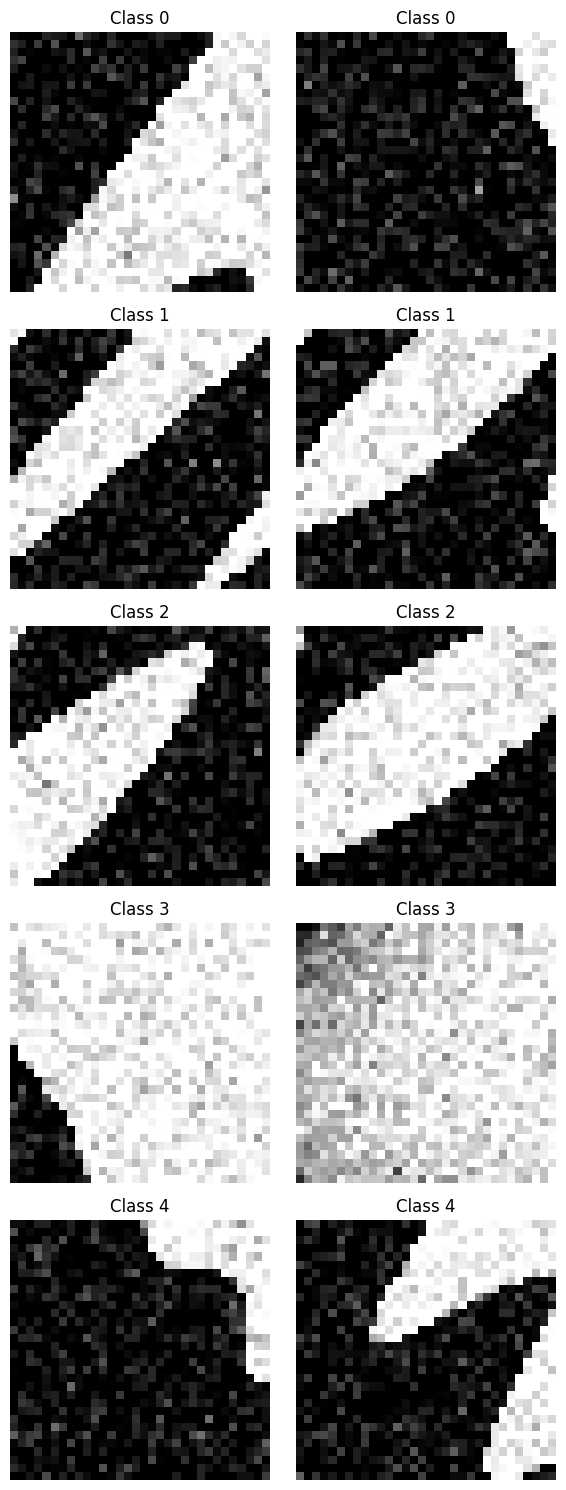

In [53]:
fig, axes = plt.subplots(classes, examples_per_class, figsize=(6, 15))
if classes == 1:
    axes = axes.reshape(1, -1)

for cls in range(classes):
    # Найти индексы всех изображений этого класса
    indices = np.where(y_ == cls)[0]
    # Выбрать первые `examples_per_class` (можно случайные)
    chosen = indices[:examples_per_class]
    
    for ex, idx in enumerate(chosen):
        ax = axes[cls, ex]
        img = X_[idx, 0]   # убираем ось канала
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'Class {cls}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test_parent, y_train, y_test_parent = train_test_split(
    X_, y_, test_size=0.4, random_state=seed)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_parent, y_test_parent, test_size=0.4, random_state=seed)

# scaler = StandardScaler() # Нужен был для точек


# X_train_norm = scaler.fit_transform(X_train)   # обучаем и преобразуем
# X_test_norm = scaler.transform(X_test)         # тест с теми же параметрами
# X_val_norm = scaler.transform(X_val)         # тест с теми же параметрами
X_train_norm = X_train.astype(np.float32) / 255.0
X_val_norm = X_val.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0


y_train_onehot = np.eye(classes)[y_train.flatten()]
y_val_onehot = np.eye(classes)[y_val.flatten()]

# model = NeuralNetwork([dims, 10, 20, 40, 80, 40, 20, 10, classes], 
#                       ['relu', 'relu', 'relu', 'sigmoid', 'relu', 'relu', 'relu', 'linear'])

final_spatial_size = 32 // (2 ** 4)   # = 2
flatten_size = (2 * length) * final_spatial_size * final_spatial_size   # = 8*length

model = CNN([
    Conv2DLayer(1, length, kernel_size=3, padding=1, activation='relu'),
    MaxPool2D(pool_size=2, stride=2),
    Conv2DLayer(length, length, kernel_size=3, padding=1, activation='relu'),
    MaxPool2D(pool_size=2, stride=2),
    Conv2DLayer(length, 2 * length, kernel_size=3, padding=1, activation='relu'),
    MaxPool2D(pool_size=2, stride=2),
    Conv2DLayer(2 * length, 2 * length, kernel_size=3, padding=1, activation='relu'),
    MaxPool2D(pool_size=2, stride=2),
    Flatten(),
    DenseLayer(flatten_size, 128, activation='relu'),
    DenseLayer(128, classes, activation='linear')
])


batch_size = 32       
epochs = 10000
patience = 20
best_val_loss = float('inf')
no_improve = 0
hist = []               

ts = time()

for epoch in range(epochs):
    # Перемешивание индексов обучающей выборки
    indices = np.random.permutation(len(X_train_norm))
    epoch_losses = []    # потери по батчам

    # Обучение по батчам
    for i in range(0, len(X_train_norm), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_norm[batch_idx]
        y_batch = y_train_onehot[batch_idx]
        loss = model.train_step(X_batch, y_batch, softmax_cross_entropy, lr=0.001)
        epoch_losses.append(loss)

    avg_train_loss = np.mean(epoch_losses)   # средняя потеря за эпоху

    # Валидация (на всей валидационной выборке)
    y_pred_val = model.forward(X_val_norm)
    val_loss, _ = softmax_cross_entropy(y_pred_val, y_val_onehot)

    hist.append((avg_train_loss, val_loss))

    # Ранняя остановка
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, loss: {avg_train_loss:.6f}, val_loss: {val_loss:.6f}')

total_time = time() - ts
total_epochs = len(hist)
avg_time_per_epoch = total_time / total_epochs if total_epochs > 0 else 0

print(f"Training time: {total_time:.2f} sec")
print(f"Total epochs: {total_epochs}")
print(f"Average time per epoch: {avg_time_per_epoch:.4f} sec")

hist = np.array(hist)

Epoch 0, loss: 2.227447, val_loss: 1.483562
Epoch 10, loss: 0.910321, val_loss: 0.964006
Epoch 20, loss: 0.796494, val_loss: 1.009778
Epoch 30, loss: 0.788491, val_loss: 0.768007
Epoch 40, loss: 0.755106, val_loss: 0.742070
Epoch 50, loss: 0.814568, val_loss: 0.839828
Epoch 60, loss: 0.519126, val_loss: 0.662865
Epoch 70, loss: 0.450443, val_loss: 0.565396
Epoch 80, loss: 0.526168, val_loss: 0.697318
Epoch 90, loss: 0.419503, val_loss: 0.486288
Epoch 100, loss: 0.471300, val_loss: 0.643794
Epoch 110, loss: 0.497772, val_loss: 0.449979
Epoch 120, loss: 0.386636, val_loss: 1.024322
Epoch 130, loss: 0.404660, val_loss: 0.451274
Epoch 140, loss: 0.462702, val_loss: 0.456433
Epoch 150, loss: 1.319688, val_loss: 0.500779
Early stopping at epoch 154
Training time: 1110.45 sec
Total epochs: 155
Average time per epoch: 7.1642 sec


In [55]:
hist = np.array(hist)

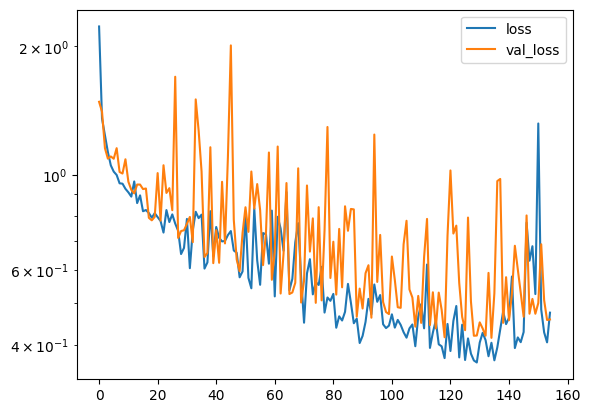

In [56]:
# X_test, y_test = X_test_parent, y_test_parent
# X_test_norm = scaler.transform(X_test)     

plt.yscale('log')
plt.plot(hist[:, 0], label="loss")
plt.plot(hist[:, 1], label="val_loss")
plt.legend()

In [57]:
predicts = predict_classification(model, X_test_norm, task='multiclass')

metrics = classification_metrics(y_test, predicts, task='multiclass')
print(metrics)

{'accuracy': 0.8125, 'precision': 0.8166258806929794, 'recall': 0.813911778333219, 'f1': 0.8094197973230886}


По итогу, модель на numpy работает гораздо быстрее, чем numba версия. Возможно, следовало бы повысить размер kernel или ещё каким-либо образом повысить нагрузку, но при экспериментах это ничего не дало